# Why JAX — differentiable inference, in the language of SED fitting

Traditional SED fitting (`emcee` + Prospector / Bagpipes / CIGALE) is
gradient-free: at every step the sampler queries the likelihood and
guesses the next move. In 10–30 dimensions, with 10⁴ likelihood calls
per chain step, a single galaxy takes hours.

Tengri builds the same physics — stellar populations, dust, nebular
emission, AGN, IGM — entirely from JAX primitives. The model is
differentiable. The likelihood and its gradient come together, at no
extra cost. Gradient-based samplers (NUTS, HMC, VI) then *use* that
gradient to climb the posterior efficiently.

The figures below make this concrete: an astronomer-readable map of
the posterior gradient, and how that translates into wall-clock time.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

from pathlib import Path
from time import perf_counter

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    Fitter,
    Observation,
    Photometry,
    SEDModel,
    generate_mock,
    load_ssp_data,
    plot,
    recipes,
)

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

W0521 03:05:57.130029 18797614 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


W0521 03:06:39.284664 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:39.288350 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## A minimal star-forming galaxy

`recipes.mock_recovery_minimal()` is the cheapest stable model — a
truncated-skew-normal SFH, single dust optical depth, no nebular
physics. Five free parameters; tractable in seconds.

In [2]:
SSP = Path("../data/fsps_prsc_miles_chabrier.h5")
if not SSP.exists():
    SSP = Path(tengri.download_ssp("fsps_prsc_miles_chabrier"))
ssp = load_ssp_data(str(SSP))

obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z", "wise_w1"])
)
model = SEDModel.build(ssp_data=ssp, observation=obs, **recipes.mock_recovery_minimal())

truth = model.spec.sample(jax.random.PRNGKey(0))
mock = generate_mock(model, truth, key=jax.random.PRNGKey(1), snr=20.0)
flux_obs, noise = mock["flux_obs"], mock["noise"]

W0521 03:06:39.508632 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:39.535218 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:39.539063 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
/Users/suchethacooray/.claude-squad/worktrees/cs/otenbokso-udatep_18b118cf202eb770/src/tengri/forward/sed_model.py:836: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To 

W0521 03:06:39.754903 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:39.860783 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:39.933943 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:06:40.130124 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:06:40.377792 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:40.397696 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:40.447254 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:06:40.603542 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:40.636533 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:40.640373 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:06:40.879703 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:06:41.358592 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.381365 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.385274 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.389264 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.392699 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.396355 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.400283 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.496174 18796289 pjrt_executable.cc:638] 

W0521 03:06:41.580533 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.613538 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.652538 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.704246 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.750616 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:06:41.922417 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:41.984830 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:06:42.079025 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:06:42.896724 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Figure 1 — the posterior gradient

Two of the free parameters, varied on a 60×60 grid with the rest fixed
at truth: the peak SFR and the birth-cloud optical depth. Left panel:
the log-posterior surface, with contours at 1σ / 2σ / 3σ. Right panel:
`jax.grad` of the same quantity, plotted as a vector field.

A gradient-free sampler explores by trial-and-error; a gradient-based
sampler reads the arrows. In one or two dozen dimensions that is the
difference between hours and seconds.

W0521 03:06:51.527447 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


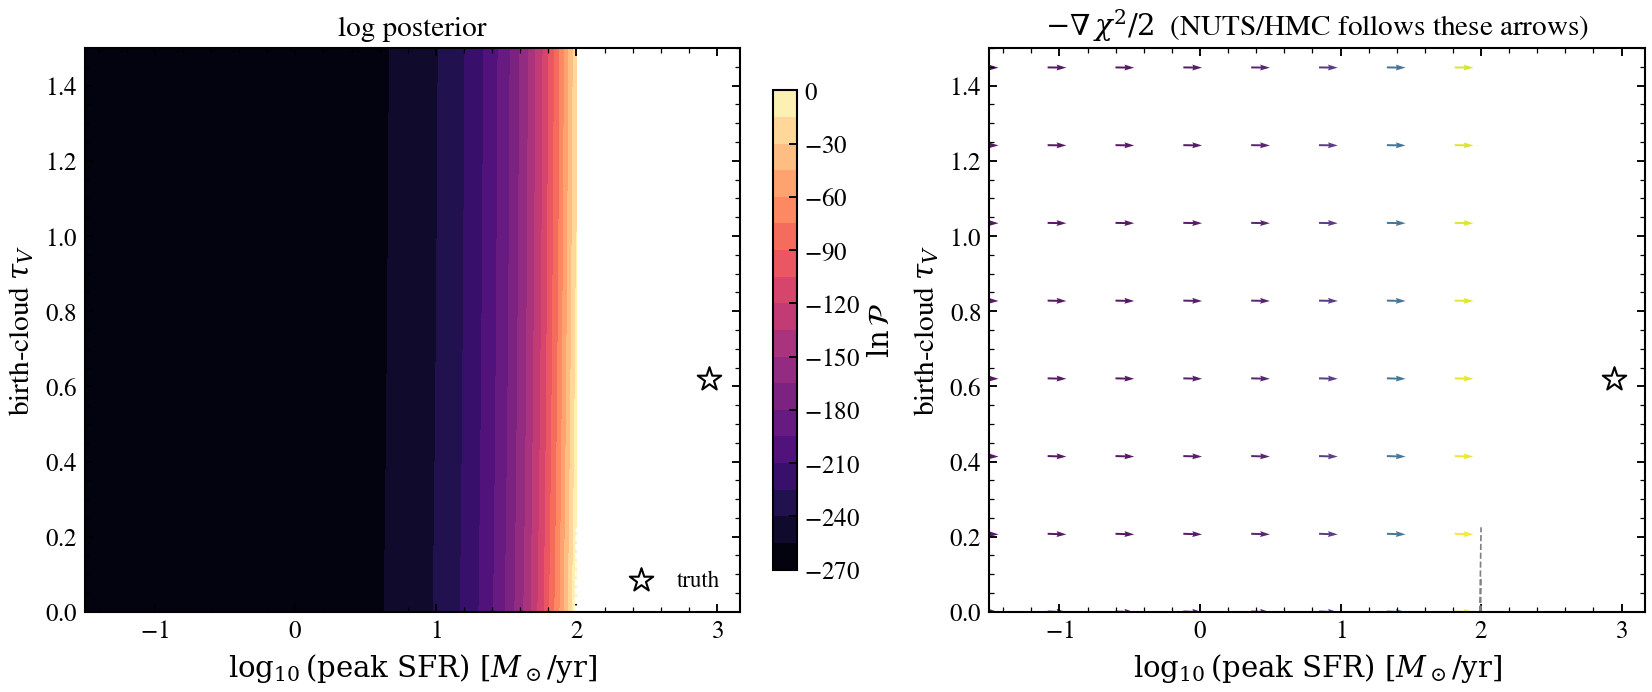

In [3]:
log_sfr_grid = np.linspace(-1.5, 2.0, 30)
tau_grid = np.linspace(0.0, 1.5, 30)
LSFR, TAU = np.meshgrid(log_sfr_grid, tau_grid, indexing="ij")

base = dict(truth)
free_keys = ("sfh_tsnorm_log_peak_sfr", "dust_tau_bc")


def neg_log_post(log_sfr, tau):
    p = dict(base)
    p[free_keys[0]] = log_sfr
    p[free_keys[1]] = tau
    flux_pred = model.predict_observables(p).phot_fnu
    chi2 = jnp.sum(((flux_pred - flux_obs) / noise) ** 2)
    return 0.5 * chi2  # uniform priors → χ²/2 = -ln posterior up to const


# Sequentialise: vmap-of-vmap of the orchestrator state pytree
# explodes memory (n_age × n_wave × n_grid). Plain JIT'd scalar
# calls reuse one set of buffers and stay well under a GB.
neg_log_post_jit = jax.jit(neg_log_post)
grad_jit = jax.jit(jax.grad(neg_log_post, argnums=(0, 1)))

nll_grid = np.zeros_like(LSFR)
g_log_sfr = np.zeros_like(LSFR)
g_tau = np.zeros_like(LSFR)
for i in range(LSFR.shape[0]):
    for j in range(LSFR.shape[1]):
        nll_grid[i, j] = float(neg_log_post_jit(LSFR[i, j], TAU[i, j]))
        gx, gy = grad_jit(LSFR[i, j], TAU[i, j])
        g_log_sfr[i, j] = float(gx)
        g_tau[i, j] = float(gy)

log_post = -(nll_grid - nll_grid.min())  # peak at zero
step_x, step_y = -g_log_sfr, -g_tau  # ascend the posterior
mag = np.hypot(step_x, step_y)
step_x = step_x / (mag + 1e-12)
step_y = step_y / (mag + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
levels = -np.array([0.5 * s * s for s in (1.0, 2.0, 3.0)])[::-1]
cs = axes[0].contourf(LSFR, TAU, log_post, levels=20, cmap="magma")
axes[0].contour(LSFR, TAU, log_post, levels=levels, colors="white", linewidths=0.8)
axes[0].scatter(
    [truth[free_keys[0]]],
    [truth[free_keys[1]]],
    marker="*",
    s=140,
    c="white",
    edgecolor="k",
    zorder=5,
    label="truth",
)
axes[0].set_xlabel(r"$\log_{10}(\mathrm{peak\ SFR})\ [M_\odot/\mathrm{yr}]$")
axes[0].set_ylabel(r"birth-cloud $\tau_V$")
axes[0].set_title("log posterior")
axes[0].legend(loc="lower right", frameon=False)
fig.colorbar(cs, ax=axes[0], shrink=0.85, label=r"$\ln \mathcal{P}$")

stride = 4
axes[1].contour(LSFR, TAU, log_post, levels=levels, colors="0.5", linewidths=0.8)
axes[1].quiver(
    LSFR[::stride, ::stride],
    TAU[::stride, ::stride],
    step_x[::stride, ::stride],
    step_y[::stride, ::stride],
    mag[::stride, ::stride],
    cmap="viridis",
    pivot="middle",
    scale=35,
    width=0.003,
    alpha=0.9,
)
axes[1].scatter(
    [truth[free_keys[0]]],
    [truth[free_keys[1]]],
    marker="*",
    s=140,
    c="white",
    edgecolor="k",
    zorder=5,
)
axes[1].set_xlabel(r"$\log_{10}(\mathrm{peak\ SFR})\ [M_\odot/\mathrm{yr}]$")
axes[1].set_ylabel(r"birth-cloud $\tau_V$")
axes[1].set_title(r"$-\nabla\, \chi^2 / 2$  (NUTS/HMC follows these arrows)")
fig.savefig(FIG_DIR / "01_gradient_map.png", dpi=300, bbox_inches="tight")

Three lines of code carry that whole picture:

In [4]:
def loss(p):
    return 0.5 * jnp.sum(((model.predict_observables(p).phot_fnu - flux_obs) / noise) ** 2)


grad_at_truth = jax.grad(loss)(truth)
{k: float(v) for k, v in grad_at_truth.items() if k in free_keys}

W0521 03:07:24.845801 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:07:25.054869 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:07:26.158489 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:07:26.162659 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:07:26.166305 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:07:26.214357 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:07:26.218762 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:25.682513 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:25.905087 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0521 03:11:27.047683 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:27.193027 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:27.197295 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:27.201965 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:27.469754 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:27.684407 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:28.721941 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:28.758820 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:28.824493 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:28.831113 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


{'dust_tau_bc': -4.771049600937636,
 'sfh_tsnorm_log_peak_sfr': 14.39605417988824}

## Figure 2 — forward-model throughput

A single forward call (the JIT'd `predict_observables`) versus a
`vmap` over 10 000 parameter draws. The batched call is far below
10 000× the single-call cost: cold-compile is paid once, then XLA
broadcasts the same compiled graph across the batch axis. This is
the unit of speed-up that lets gradient samplers, population fits,
and posterior-predictive sweeps fit on a laptop.

W0521 03:11:29.044733 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:29.079959 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:29.191985 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:29.846428 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:30.322764 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:30.339197 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:30.707471 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:30.927313 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0521 03:11:51.200798 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:51.208327 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:51.293348 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:51.324021 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  MAP init done (loss=36.93)


W0521 03:11:52.855475 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:56.363840 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:56.578312 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


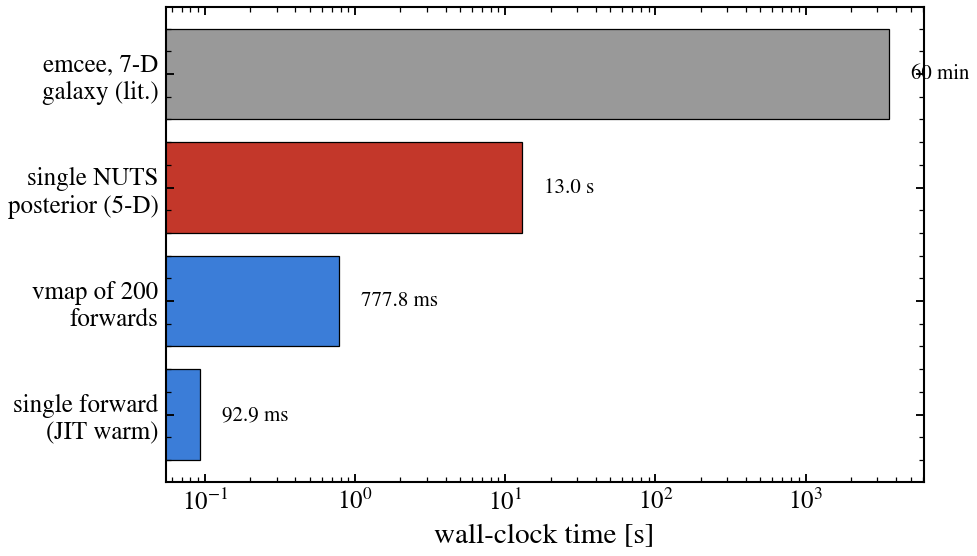

In [5]:
# Warm the JIT cache.
_ = model.predict_observables(truth).phot_fnu.block_until_ready()

t0 = perf_counter()
for _ in range(50):
    _ = model.predict_observables(truth).phot_fnu.block_until_ready()
t_single = (perf_counter() - t0) / 50

tengri.clear_shared_caches()  # free graphs from the gradient figure
n_batch = 200
keys = jax.random.split(jax.random.PRNGKey(5), n_batch)
batch_params = jax.vmap(model.spec.sample)(keys)
forward = jax.jit(jax.vmap(lambda p: model.predict_observables(p).phot_fnu))

_ = forward(batch_params).block_until_ready()  # cold-compile
t0 = perf_counter()
_ = forward(batch_params).block_until_ready()
t_batch = perf_counter() - t0

t0 = perf_counter()
posterior = Fitter(model, flux_obs, noise, data_type="photometry").run(
    method="mcmc_nuts",
    key=jax.random.PRNGKey(2),
    n_warmup=300,
    n_samples=300,
)
t_nuts = perf_counter() - t0

bars = {
    "single forward\n(JIT warm)": t_single,
    f"vmap of {n_batch}\nforwards": t_batch,
    "single NUTS\nposterior (5-D)": t_nuts,
    "emcee, 7-D\ngalaxy (lit.)": 3600.0,
}
fig2, ax = plt.subplots(figsize=(6.8, 4.0))
colors = ["#3b7dd8", "#3b7dd8", "#c3372a", "0.6"]
ax.barh(list(bars), list(bars.values()), color=colors, edgecolor="k", linewidth=0.6)
ax.set_xscale("log")
ax.set_xlabel("wall-clock time [s]")
for i, v in enumerate(bars.values()):
    if v < 1.0:
        label = f"{v * 1e3:.1f} ms"
    elif v < 120:
        label = f"{v:.1f} s"
    else:
        label = f"{v / 60:.0f} min"
    ax.text(v * 1.4, i, label, va="center", fontsize=10)
fig2.tight_layout()
fig2.savefig(FIG_DIR / "01_wallclock.png", dpi=300, bbox_inches="tight")

## Two switches worth knowing

**`compile=`** controls how the forward model is JIT-wrapped at build
time. `per_component` (the default) compiles each `SEDComponent`
independently — fast cold start, friendly to notebook edits. `fused`
compiles the full pipeline as one graph — slower first call, fastest
steady state, what you want inside a population fit.

In [6]:
model_fused = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    compile="fused",
    **recipes.mock_recovery_minimal(),
)

W0521 03:11:57.117906 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:57.124515 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:57.129996 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:57.227551 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:57.243978 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:57.250575 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:57.310265 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:57.340821 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
/Users/suchethacooray/.claude-squad/worktrees/cs/otenbokso-udatep_18b118cf202eb770/src/tengri/forward/sed_model.py:836: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()
W0521 03:11:57.374390 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:57.385143 18796289 pjrt_execu

W0521 03:11:57.636865 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:57.898512 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:58.028258 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:58.509822 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0521 03:11:59.477964 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:59.533098 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:11:59.540427 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:11:59.814704 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:12:00.925690 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:00.962658 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:00.969633 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:00.976365 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:00.983067 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:00.988528 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:00.994489 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:12:01.214848 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:01.226572 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:01.285013 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:01.403535 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:12:01.472016 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:12:01.561532 18796289 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


**Persistent JAX cache.** `import tengri` enables an on-disk JIT cache
at `~/.cache/tengri_jax_cache`. Restarting the kernel or launching a
Slurm worker does not trigger recompilation of unchanged components;
the first forward pass of a fresh process is already warm. Cache
management lives in four verbs: `tengri.lean` (default, drop the
engine after each fit), `tengri.persistent` (keep it for repeated
same-shape fits), `tengri.gc` (one-shot collect), and
`tengri.clear_shared_caches()` (full reset for clean benchmarking).

## What this opens up

Population fits across thousands of galaxies become tractable on a
laptop, not just a cluster. Hierarchical priors, where each galaxy's
posterior informs a shared parent distribution, are sampled jointly
rather than post-hoc. High-dimensional non-parametric SFHs (≥30
bins) are sampled in minutes. The next notebooks build the model up
component by component.